In [63]:
#importlar
import numpy as np 
import pandas as pd 
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import model_selection
import matplotlib.pyplot as plt 
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
%matplotlib inline

In [64]:
df=pd.read_excel("METAS.xlsx")

In [65]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.04999923706055,45.0,38.0,38.22999954223633,38.084515,573576400
1,2012-05-21,36.529998779296875,36.65999984741211,33.0,34.029998779296875,33.900501,168192700
2,2012-05-22,32.61000061035156,33.59000015258789,30.940000534057617,31.0,30.882032,101786600
3,2012-05-23,31.3700008392334,32.5,31.360000610351562,32.0,31.878227,73600000
4,2012-05-24,32.95000076293945,33.209999084472656,31.770000457763672,33.029998779296875,32.904308,50237200


In [66]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [67]:
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df.set_index('Date', inplace=True)

# Display the data types
df.dtypes

Open          object
High          object
Low           object
Close         object
Adj Close    float64
Volume         int64
dtype: object

In [68]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title('META Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

TypeError: 'value' must be an instance of str or bytes, not a datetime.datetime

In [69]:
print(df.dtypes)


Open          object
High          object
Low           object
Close         object
Adj Close    float64
Volume         int64
dtype: object


In [70]:
columns_to_convert = ['Open', 'High', 'Low', 'Close']

for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')


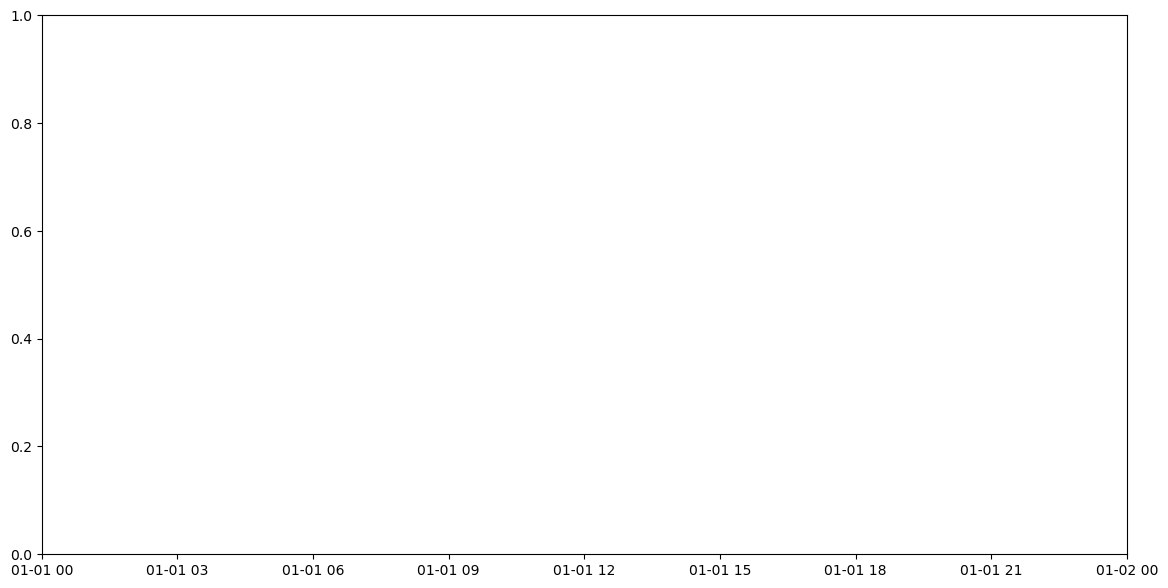

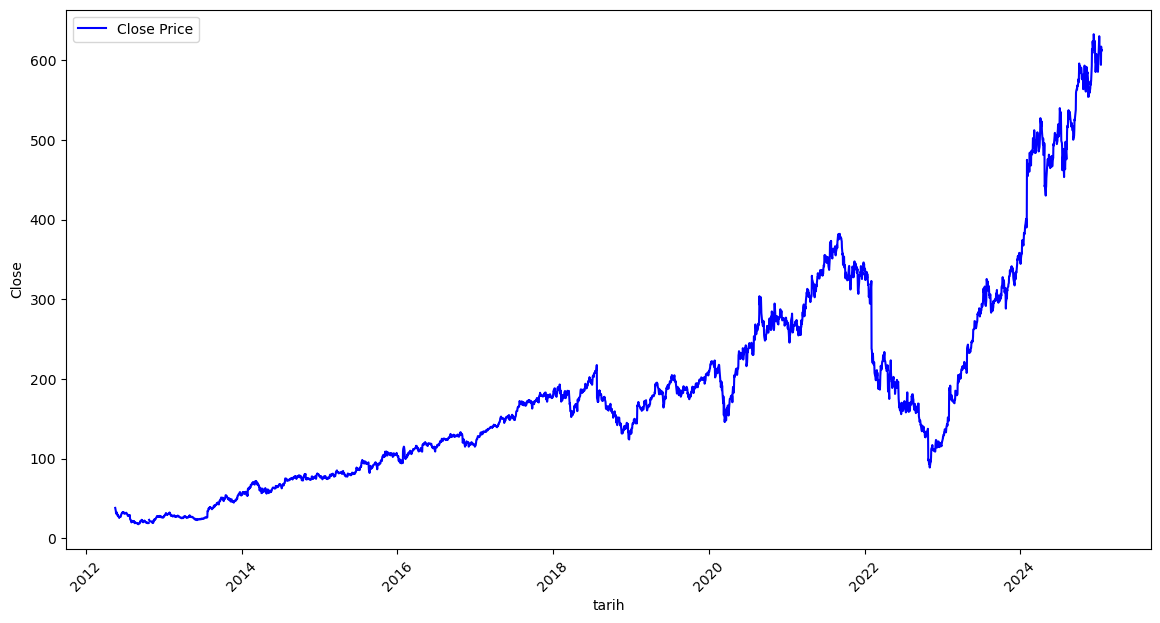

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.xlabel('tarih')
plt.ylabel('Close')
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [72]:
correlation_matrix = df.corr()
# Korelasyon tablosunu 
correlation_matrix

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999823,0.999805,0.999602,0.999603,-0.380809
High,0.999823,1.000000,0.999780,0.999816,0.999815,-0.377786
Low,0.999805,0.999780,1.000000,0.999833,0.999832,-0.384308
Close,0.999602,0.999816,0.999833,1.000000,0.999998,-0.381405
Adj Close,0.999603,0.999815,0.999832,0.999998,1.000000,-0.381578
Volume,-0.380809,-0.377786,-0.384308,-0.381405,-0.381578,1.000000


In [73]:
X = df[['Open', 'High', 'Low', 'Adj Close', 'Volume']]
y = df['Close']
X.isnull().sum()

Open         6
High         7
Low          3
Adj Close    0
Volume       0
dtype: int64

In [74]:
X = X.fillna(X.mean())
y = y.fillna(y.mean()) 
X.isnull().sum()
print("aa")
y.isnull().sum()
print(X.shape, y.shape)


aa
(3186, 5) (3186,)


In [75]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_tahmin = model.predict(X_test)
mse = mean_squared_error(y_test, y_tahmin)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_tahmin)
mse,rmse,r2

(29.382440650859593, 5.420557226970267, 0.9984512583350876)

In [76]:
cross_val_score(model,X_train,y_train,cv=10,scoring="neg_mean_squared_error")
print(np.mean(-cross_val_score(model,X_train,y_train,cv=10,scoring="neg_mean_squared_error")))

11.335776551422683


In [77]:
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
lm=sm.OLS(y_train,X_train_const)
model=lm.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.627e+05
Date:                Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                        05:43:36   Log-Likelihood:                -5868.7
No. Observations:                2230   AIC:                         1.175e+04
Df Residuals:                    2224   BIC:                         1.178e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5519      0.190      2.900      0.004       0.179       0.925
Open          -0.0020      0.010     -0.204      0.839      -0.021       0.017
High          -0.0006      0.009     -0.069      0.945      -0.019       0.018
Low           -0.0015      0.011     -0.134      0.893      -0.023       0.020
Adj Close      1.0053      0.015     67.328      0.000       0.976       1.035
Volume     -2.557e-09   3.43e-09     -0.745      0.456   -9.29e-09    4.17e-09
==============================================================================
Omnibus:                     6941.280   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        449756307.013
Skew:                          46.763   Prob(JB):                         0.00
Kurtosis:                    2201.108   Cond. No.                     9.79e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.79e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""